# Sky scan

This tutorial shows how to produce a Sky scan.

For analysis setup details check the [Fitting a steady point-source with the public 14-year IceCube track data](fitting_a_source.ipynb) tutorial.

In [1]:
import numpy as np

import skyllh
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis
from skyllh.core.config import Config
from skyllh.core.source_model import PointLikeSource

cfg = Config()
datasets = skyllh.create_datasets('IceTracks-DR2', cfg=cfg)

src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

source = PointLikeSource(ra=np.radians(src_ra), dec=np.radians(src_dec))

ana = create_analysis(cfg=cfg, datasets=datasets, source=source)

100%|██████████| 136/136 [00:00<00:00, 9370.28it/s]


## Unblinding the data

After creating the analysis instance we can unblind the data for the chosen source. Hence, we initialize the analysis with a trial of the experimental data, maximize the log-likelihood ratio function for all given experimental data events, and calculate the test-statistic value. The analysis instance has the method ``unblind`` that can be used for that. This method requires a ``RandomStateService`` instance in case the minimizer does not succeed and a new set of initial values for the fit parameters need to get generated.

In [2]:
from skyllh.core.random import RandomStateService

rss = RandomStateService(3090)
ts, fitparam_values, status = ana.unblind(rss)
ns_bf = fitparam_values['ns']
gamma_bf = fitparam_values['gamma']
print(f'Unblinded results: TS={ts:.2f}, ns={ns_bf:.2f}, gamma={gamma_bf:.2f}')
print(f'Minimizer status: {status}')

Unblinded results: TS=28.77, ns=79.55, gamma=3.20
Minimizer status: {'grad': array([-3.08035275e-06, -3.17262427e-04]), 'task': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'funcalls': 13, 'nit': 10, 'warnflag': 0, 'skyllh_minimizer_n_reps': 0, 'n_llhratio_func_calls': 13}


## Producing a Sky scan near the source

Here we scan a patch of the sky around the source coordinates. We therefore define a grid of points in R.A. and Dec. and unblind the data to get a TS, ns, and gamma value at each grid point.

The ``change_source`` property of the ``Analysis`` instance allows us to change the source hypothesis of the analysis without re-initializing the analysis instance itself.


> **Compute time note**: Despite this optimization, running the following cell can take 2-3 minutes on a laptop.


In [3]:
# Produce a little sky scan around the source location

src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

ra_min = src_ra - 1.0
ra_max = src_ra + 1.0
dec_min = src_dec - 1.0
dec_max = src_dec + 1.0

nbins = 50
edges_x = np.linspace(ra_min, ra_max, nbins + 1)
edges_y = np.linspace(dec_min, dec_max, nbins + 1)
centers_x = 0.5 * (edges_x[1:] + edges_x[:-1])
centers_y = 0.5 * (edges_y[1:] + edges_y[:-1])

# Initialize the results arrays
results_ts = np.zeros((nbins, nbins), dtype=float)
results_p = np.zeros((nbins, nbins), dtype=float)
results_ns = np.zeros((nbins, nbins), dtype=float)
results_g = np.zeros((nbins, nbins), dtype=float)

for i, ra in enumerate(centers_x):
    for j, dec in enumerate(centers_y):
        # Change source position to evaluate the likelihood
        src_dec = np.radians(dec)
        src_ra = np.radians(ra)
        source = PointLikeSource(src_ra, src_dec)
        ana.change_source(source, update_detsigyield_service=False)

        # Unblind the new position
        rss = RandomStateService(3090)
        ts, fitparam_values, status = ana.unblind(rss)
        results_ts[i, j] = ts
        results_ns[i, j] = fitparam_values['ns']
        results_g[i, j] = fitparam_values['gamma']

The contours are computed assuming that Wilks' theorem holds true, that is the TS distribution follows a $\chi^2$ distribution with 2 degrees of freedom in this example where we fit the flux normalization and spectral index of a powerlaw flux.

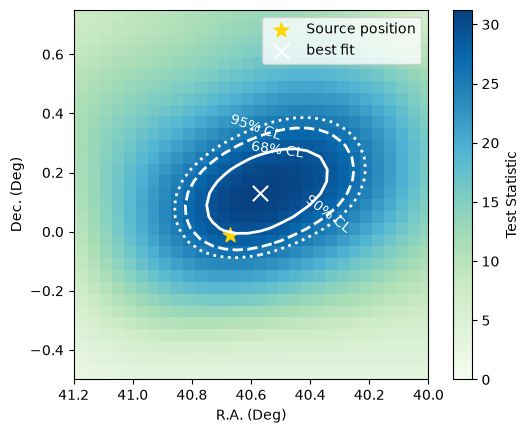

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import chi2

ts_max = results_ts.max()
chi2_68_quantile = ts_max - chi2.ppf(0.68, df=2)
chi2_90_quantile = ts_max - chi2.ppf(0.90, df=2)
chi2_95_quantile = ts_max - chi2.ppf(0.95, df=2)

idx = np.unravel_index(results_ts.argmax(), results_ts.shape)
best_dec = centers_y[idx[0]]
best_ra = centers_x[idx[1]]

X, Y = np.meshgrid(centers_x, centers_y)

src_ra = 40.67  # degrees
src_dec = -0.01

fig, ax = plt.subplots()

im = ax.pcolormesh(centers_x, centers_y, results_ts, cmap='GnBu')
ax.invert_xaxis()
contour_68 = ax.contour(
    centers_x, centers_y, results_ts, levels=[chi2_68_quantile], colors='w', linestyles='-', linewidths=2
)
contour_90 = ax.contour(
    centers_x, centers_y, results_ts, levels=[chi2_90_quantile], colors='w', linestyles='--', linewidths=2
)
contour_95 = ax.contour(
    centers_x, centers_y, results_ts, levels=[chi2_95_quantile], colors='w', linestyles=':', linewidths=2
)
ax.scatter([src_ra], [src_dec], marker='*', color='gold', s=120, label='Source position')
ax.scatter([best_ra], [best_dec], marker='x', color='w', s=120, label='best fit')

ax.set_aspect('equal')
ax.set_xlim(40, 41.2)
ax.set_ylim(-0.5, 0.75)
cbar = plt.colorbar(im)
cbar.set_label('Test Statistic')
ax.set_xlabel('R.A. (Deg)')
ax.set_ylabel('Dec. (Deg)')

ax.clabel(
    contour_68, fmt={chi2_68_quantile: '68% CL'}, fontsize=10, inline=False, inline_spacing=5, manual=[(40.5, 0.2)]
)
ax.clabel(
    contour_90, fmt={chi2_90_quantile: '90% CL'}, fontsize=10, inline=False, inline_spacing=5, manual=[(40.1, -0.3)]
)
ax.clabel(
    contour_95, fmt={chi2_95_quantile: '95% CL'}, fontsize=10, inline=False, inline_spacing=5, manual=[(40.6, 0.4)]
)

ax.invert_xaxis()
plt.legend()
plt.show()